<div dir="rtl">

# سؤال ۵: تراکم جغرافیایی آگهی‌ها

می‌خواهیم ببینیم آگهی‌ها روی نقشه ایران کجا متراکم‌ترند.
داده از خروجی پایپ‌لاین اصلی خونده مبشه

</div>

<div dir="rtl">

## ۱. خواندن داده

ستون `coord_status` وضعیت مختصات هر آگهی رو نشان می‌ده. فقط آگهی‌هایی که وضعیت‌شان `ok` است مختصات قابل اعتماد دارند. بقیه یا مختصات ندارند یا مختصات‌شان غلط یا پیش‌فرض بوده و در پری پراسسینگ خالی شده.

</div>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/Divar_cleaned.parquet")

print(df.shape)
df["coord_status"].value_counts()

(999997, 79)


coord_status
ok                  636183
missing             344390
pin_chand_shahri     10315
door_az_shahr         9062
kharej                  47
Name: count, dtype: int64

<div dir="rtl">

## ۲. انتخاب نقطه‌ها برای نقشه

حدود ۶۳۶ هزار آگهی مختصات سالم دارن. ولی بعضی نقطه‌ها خیلی تکرار شدهن چون مثلا یک مشاور املاک همه آگهی‌هاش رو روی دفتر خودش پین کرده. این نقطه‌ها روی نقشه لکه داغ ساختگی درست می‌کنن

۹۹ درصد نقطه‌ها حداکثر ۴ بار تکرار شدن. نقطه‌هایی که ۱۰ بار یا بیشتر تکرار شده‌اند را کنار گذاشتیم که کمتر از ۱ درصد دادهان

</div>

In [12]:
points = df[df["coord_status"] == "ok"]
print(f"noghte haye salem: {len(points):,}")

display(points["pin_repeat_count"].describe(percentiles=[0.5, 0.9, 0.99]).round(1))

for limit in [5, 10, 20, 50]:
    count = (points["pin_repeat_count"] >= limit).sum()
    print(f"roye noghte ba hadaghal {limit} tekrar: {count:,} agahi")

noghte haye salem: 636,183


count    636183.0
mean          1.3
std           3.7
min           1.0
50%           1.0
90%           1.0
99%           4.0
max         115.0
Name: pin_repeat_count, dtype: Float64

roye noghte ba hadaghal 5 tekrar: 6,134 agahi
roye noghte ba hadaghal 10 tekrar: 3,952 agahi
roye noghte ba hadaghal 20 tekrar: 2,479 agahi
roye noghte ba hadaghal 50 tekrar: 1,041 agahi


<div dir="rtl">

## ۳. نقشه تراکم آگهی‌ها

نقشه به شش‌ضلعی‌های کوچیک تقسیم شده و رنگ هر کدوم تعداد آگهی‌های اون رو نشان میده. مقیاس رنگ لگاریتمی است چون تهران ده‌ها هزار آگهی داره و شهرهای کوچک چند ده تا. در مقیاس معمولی فقط تهران دیده می‌شد.

سمت چپ کل ایرانه و سمت راست تهرانه که روش زوم شده 

</div>

noghte haye naghshe: 632,231


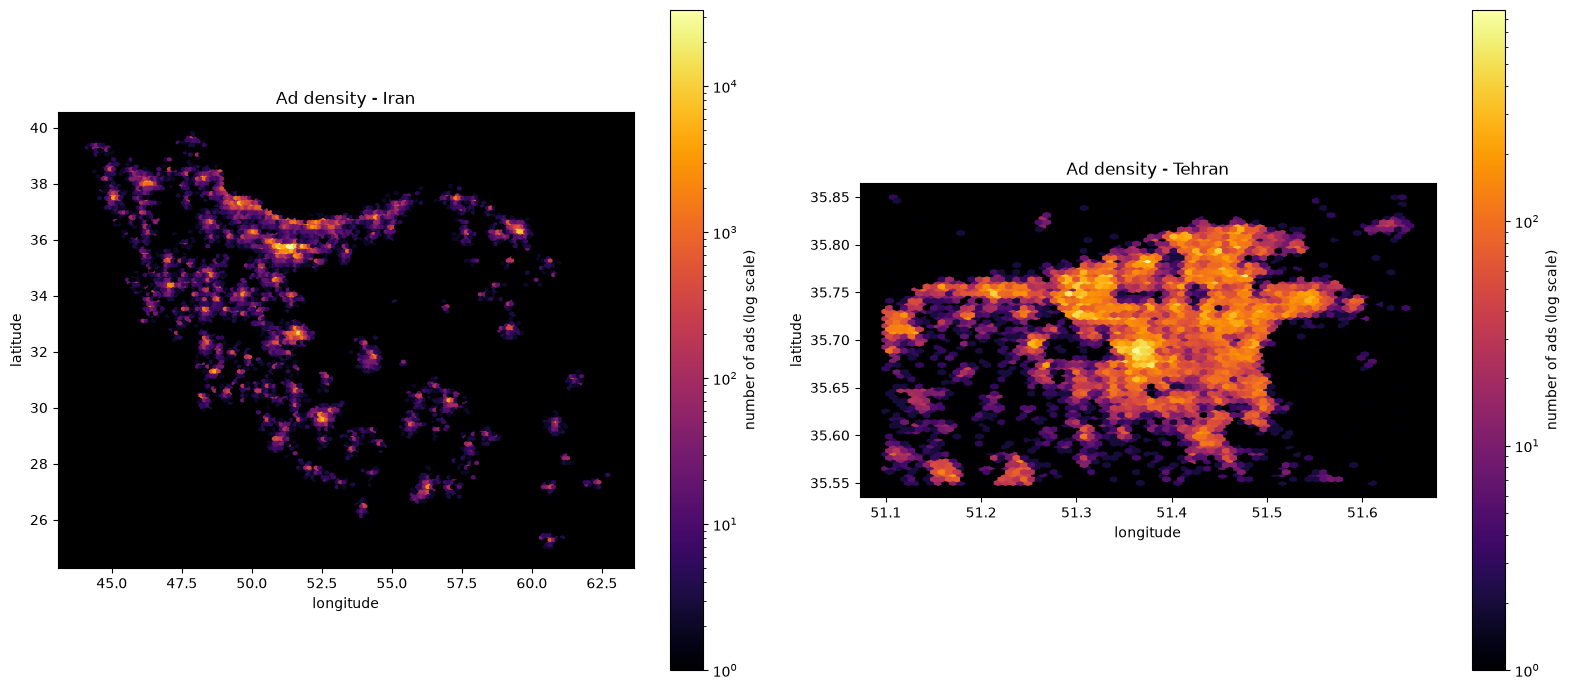

In [13]:
map_points = points[points["pin_repeat_count"] < 10]
print(f"noghte haye naghshe: {len(map_points):,}")
lat, lon = "location_latitude", "location_longitude"

tehran = map_points[map_points[lat].between(35.55, 35.85) & map_points[lon].between(51.1, 51.65)]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

hb1 = axes[0].hexbin(map_points[lon], map_points[lat], gridsize=150, bins="log", cmap="inferno", mincnt=1)
axes[0].set_title("Ad density - Iran")
fig.colorbar(hb1, ax=axes[0], label="number of ads (log scale)")

hb2 = axes[1].hexbin(tehran[lon], tehran[lat], gridsize=70, bins="log", cmap="inferno", mincnt=1)
axes[1].set_title("Ad density - Tehran")
fig.colorbar(hb2, ax=axes[1], label="number of ads (log scale)")

for ax in axes:
    ax.set_facecolor("black")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

<div dir="rtl">

## ۴. سهم شهرها و محله‌های تهران

نقشه جای لکه‌ها را نشان میده ولی برای جواب دقیق عدد هم لازمههه. سهم شهرها از روی ستون شهر حساب شده که برای همه آگهی‌ها پر است حتی اونایی که مختصات ندارن

</div>

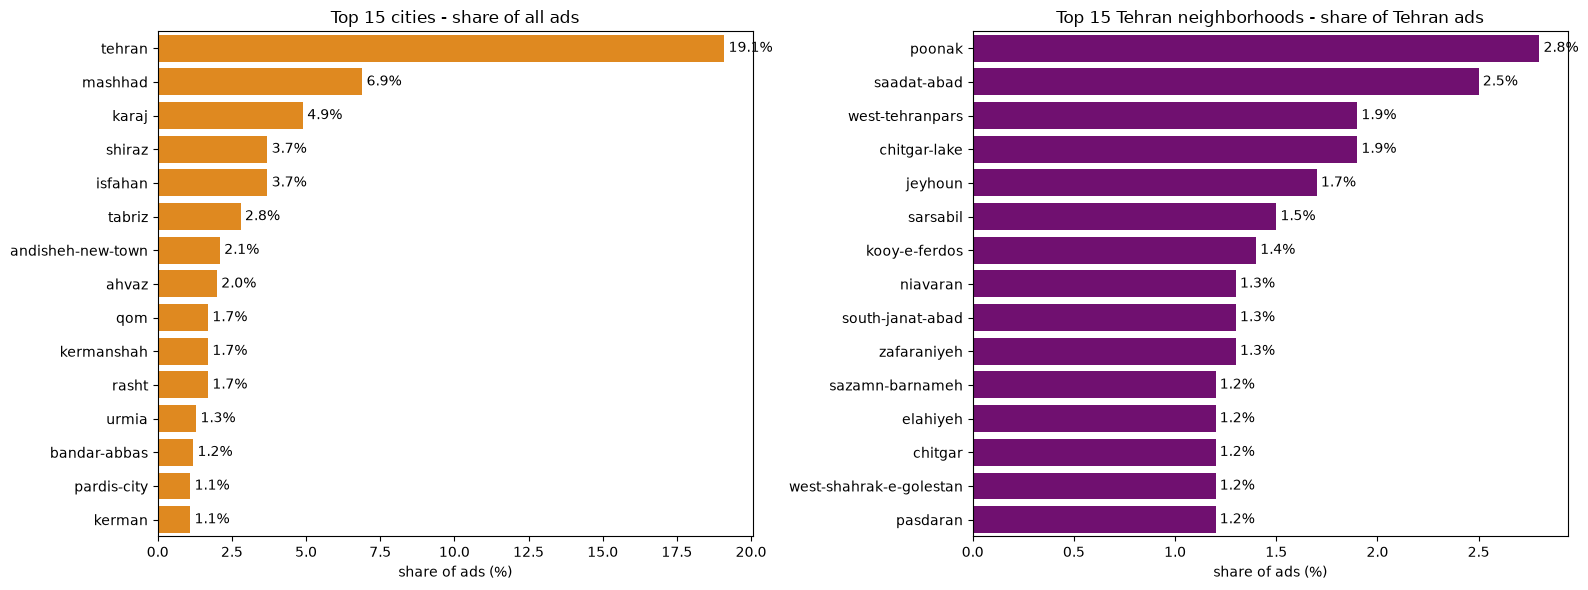

sahm 5 shahr aval: 38.3%


In [14]:
city_share = (df["city_slug"].value_counts().head(15) / len(df) * 100).round(1)
tehran_ads = df[(df["city_slug"] == "tehran") & (df["neighborhood_slug"] != "unknown")]
hood_share = (tehran_ads["neighborhood_slug"].value_counts().head(15) / len(tehran_ads) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=city_share.values, y=city_share.index, ax=axes[0], color="darkorange")
axes[0].bar_label(axes[0].containers[0], fmt="%.1f%%", padding=3)
axes[0].set_title("Top 15 cities - share of all ads")
axes[0].set_xlabel("share of ads (%)")
axes[0].set_ylabel("")

sns.barplot(x=hood_share.values, y=hood_share.index, ax=axes[1], color="purple")
axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%", padding=3)
axes[1].set_title("Top 15 Tehran neighborhoods - share of Tehran ads")
axes[1].set_xlabel("share of ads (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"sahm 5 shahr aval: {city_share.head(5).sum():.1f}%")

<div dir="rtl">

## ۵. نقشه تعاملی

این نقشه روی نقشه واقعی ایران کشیده شده و می‌شه روش زوم کنید و لذت ببریذ. برای سرعت بیشتر از یک نمونه تصادفی ۱۵۰ هزار نقطه‌ای استفاده شده. نقشه در فایل `data/eda_05_heatmap.html`ذخیره می‌شود و در مرورگر باز می‌شود. گیت‌هاب این نقشه رو نشون نمیده

</div>

In [16]:
import folium
from folium.plugins import HeatMap

sample = map_points.sample(150_000, random_state=42)

m = folium.Map(location=[32.5, 53.7], zoom_start=5, tiles="Esri.WorldGrayCanvas")
HeatMap(sample[[lat, lon]].values.tolist(), radius=6, blur=8, min_opacity=0.3).add_to(m)

m.save("../data/eda_05_heatmap.html")
m